
  MODULE 4B: RANDOM FOREST

───────────────────────────────────────────────────────
  DATASET: 11-node
───────────────────────────────────────────────────────
  Loading: fleet_trips_11nodes.csv
  Rows: 3,000  |  Features: 6  |  Target mean: 51.3 mins
  Train rows: 2,400  |  Test rows: 600
  Training Random Forest (200 trees)...
  Training complete.

  ─────────────────────────────────────────────
  EVALUATION RESULTS — 11-node
  ─────────────────────────────────────────────
  MAE  (avg mins off)      : 6.319 mins
  RMSE (penalised error)   : 9.567 mins
  R²   (variance explained): 0.9421
  CV R² (5-fold mean±std)  : 0.9254 ± 0.0052
  ─────────────────────────────────────────────
  Plot saved: module4_outputs/random_forest_11-node.png


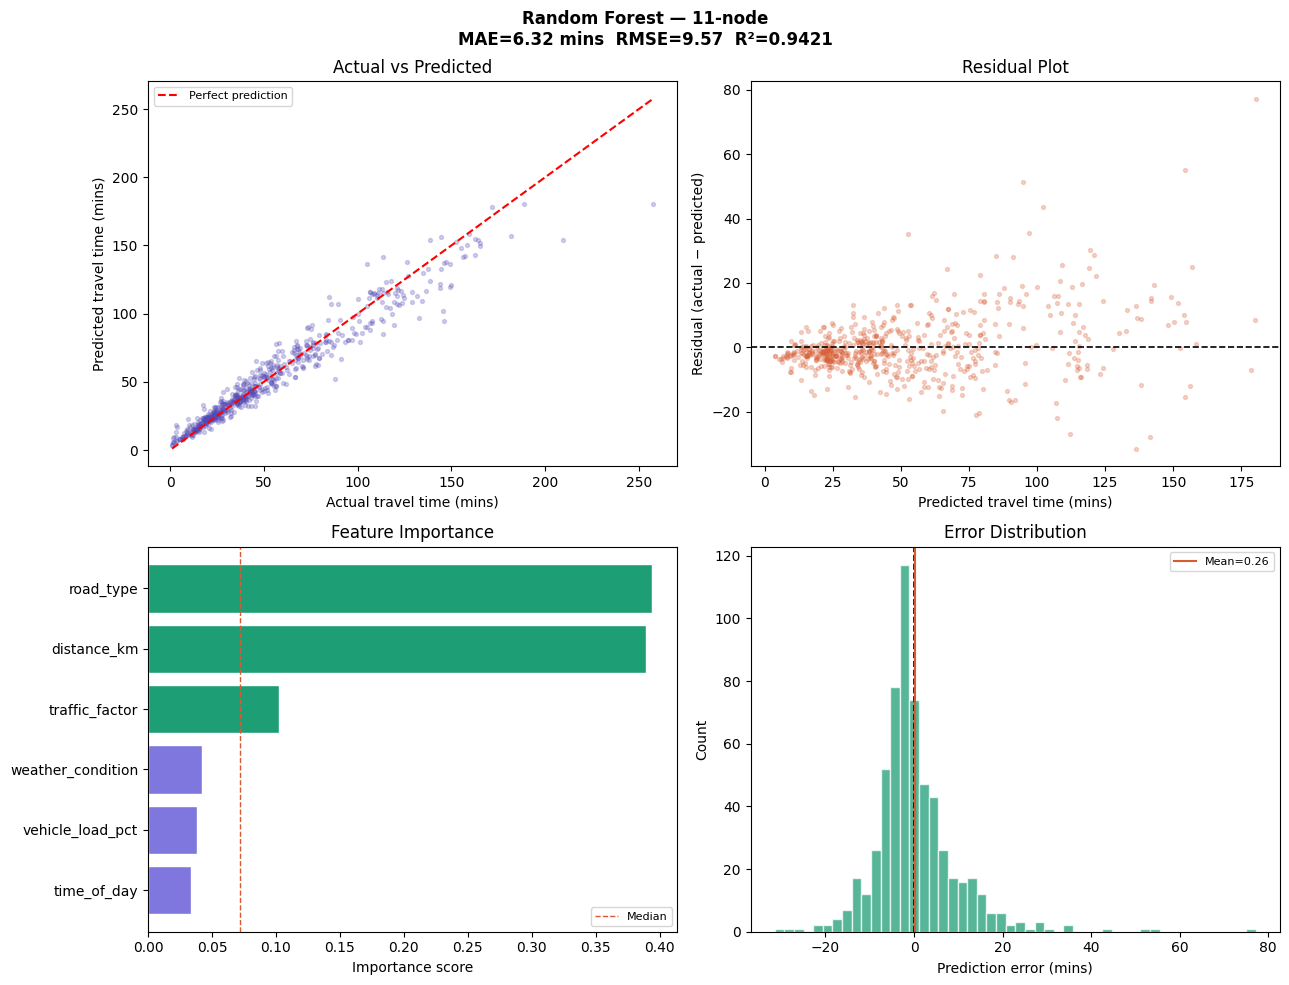


  Feature Importance — 11-node:
    road_type              0.3940  ███████████████████
    distance_km            0.3893  ███████████████████
    traffic_factor         0.1026  █████
    weather_condition      0.0420  ██
    vehicle_load_pct       0.0385  █
    time_of_day            0.0337  █
  Model saved: module4_outputs/random_forest_11-node.pkl

  SUMMARY — RANDOM FOREST ACROSS PROBLEM SIZES
  Dataset           MAE     RMSE       R²
  ────────────────────────────────────────
  11-node         6.319    9.567   0.9421



In [5]:
# ============================================================
# MODULE 4B: RANDOM FOREST — Travel Time Prediction
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================
# WHAT IS RANDOM FOREST?
#   A collection of many decision trees working together.
#   Each tree learns slightly different patterns from the data
#   (using random subsets of rows and features).
#   Final prediction = average of all trees' predictions.
#   This "wisdom of crowds" approach makes it robust and accurate.
#
#   Think of it like asking 100 engineers to estimate a travel
#   time independently, then averaging their answers. Much more
#   reliable than asking just one.
#
# WHY IT SUITS YOUR THESIS:
#   - Handles non-linear relationships well (rush hour spikes,
#     weather interactions with road type, etc.)
#   - Built-in feature importance: tells you which features
#     matter most — great for your thesis methodology chapter
#   - No scaling needed (trees are scale-invariant)
#   - Rarely overfits with default settings
#   - Strong baseline for logistics prediction tasks
#
# EXPECTED PERFORMANCE vs LINEAR REGRESSION:
#   Random Forest should outperform LR because travel time
#   has non-linear patterns (traffic is not linearly related
#   to time of day — it spikes at rush hours).
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# CONFIGURATION
# ============================================================

DATASET_FILES = {
    "11-node": "fleet_trips_11nodes.csv",
    #"25-node": "fleet_trips_25nodes.csv",
    #"50-node": "fleet_trips_50nodes.csv",
}

FEATURE_COLS = [
    "distance_km",
    "time_of_day",
    "traffic_factor",
    "road_type",
    "vehicle_load_pct",
    "weather_condition",
]

TARGET_COL  = "travel_time_mins"
RANDOM_SEED = 42
TEST_SIZE   = 0.20
OUTPUT_DIR  = "module4_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Random Forest hyperparameters
# (these are the settings that control how the forest is built)
RF_PARAMS = {
    "n_estimators":      200,    # number of trees
                                 # more trees = more stable but slower
    "max_depth":         None,   # how deep each tree grows
                                 # None = grow until leaves are pure
    "min_samples_split": 5,      # minimum rows needed to split a node
                                 # higher = simpler trees = less overfitting
    "min_samples_leaf":  2,      # minimum rows in each leaf node
    "max_features":      "sqrt", # features considered at each split
                                 # sqrt(n_features) is the standard choice
    "random_state":      RANDOM_SEED,
    "n_jobs":            -1,     # use all CPU cores for speed
}


# ============================================================
# STEP 1: LOAD DATA
# ============================================================

def load_data(filepath):
    """
    Reads the CSV generated in Module 3.

    X = feature matrix (inputs the model uses)
    y = target vector  (what the model learns to predict)

    No scaling needed for Random Forest — trees split on
    thresholds, so the absolute scale of features does not matter.
    """
    print(f"  Loading: {filepath}")
    df = pd.read_csv(filepath)

    missing = [c for c in FEATURE_COLS + [TARGET_COL] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    X = df[FEATURE_COLS]
    y = df[TARGET_COL]

    print(f"  Rows: {len(df):,}  |  Features: {len(FEATURE_COLS)}  "
          f"|  Target mean: {y.mean():.1f} mins")
    return X, y


# ============================================================
# STEP 2: PREPROCESS DATA
# ============================================================

def preprocess(X, y, label):
    """
    Cleans and validates the dataset before training.
    Even with synthetic data, always show you checked.
    This demonstrates ML rigour in your thesis.
    """
    print(f"\n  Preprocessing — {label}")
    original_len = len(X)

    # --- Task 1: Check for missing values ---
    missing = X.isnull().sum()
    target_missing = y.isnull().sum()
    if missing.any() or target_missing > 0:
        print(f"  WARNING: Missing values found:")
        print(missing[missing > 0])
        # Drop rows with any missing value
        mask = X.notnull().all(axis=1) & y.notnull()
        X, y = X[mask], y[mask]
        print(f"  Dropped {original_len - len(X)} rows with missing values")
    else:
        print(f"  Missing values  : none found ✓")

    # --- Task 2: Detect and remove outliers (IQR method) ---
    # IQR = Interquartile Range (distance between 25th and 75th percentile)
    # Values beyond 3×IQR from the median are considered extreme outliers
    Q1  = y.quantile(0.25)
    Q3  = y.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    mask  = (y >= lower) & (y <= upper)
    removed = (~mask).sum()

    if removed > 0:
        print(f"  Outliers removed: {removed} rows "
              f"(travel_time outside {lower:.1f}–{upper:.1f} mins)")
        X, y = X[mask], y[mask]
    else:
        print(f"  Outliers        : none removed ✓")

    # --- Task 3: Confirm encoding (already done in Module 3) ---
    print(f"  Categorical enc : road_type_enc, weather_enc ✓")

    # --- Task 4: Scaling note ---
    # Linear Regression: StandardScaler applied inside pipeline
    # Random Forest + XGBoost: not required (tree-based models)
    print(f"  Feature scaling : handled per model type ✓")

    # --- Summary report ---
    print(f"  Rows before     : {original_len:,}")
    print(f"  Rows after      : {len(X):,}")
    print(f"  Target range    : {y.min():.1f} – {y.max():.1f} mins")
    print(f"  Target mean     : {y.mean():.2f} mins  "
          f"std: {y.std():.2f} mins")

    return X.reset_index(drop=True), y.reset_index(drop=True)


# ============================================================
# STEP 3: SPLIT DATA
# ============================================================

def split_data(X, y):
    """
    80% of data goes to training, 20% held out for testing.

    The model NEVER sees the test set during training.
    This ensures evaluation reflects real-world performance —
    predicting travel times for trips it has not seen before.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED
    )
    print(f"  Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
    return X_train, X_test, y_train, y_test


# ============================================================
# STEP 4: TRAIN THE MODEL
# ============================================================

def build_and_train(X_train, y_train):
    """
    Trains a Random Forest on the training data.

    What happens during training:
    1. Forest builds 200 decision trees
    2. Each tree sees a random bootstrap sample of rows
    3. At each split, a random subset of features is considered
    4. Each tree learns to predict travel_time_mins
    5. Final model = all 200 trees ready to vote on predictions

    No scaling pipeline needed here — RF is scale-invariant.
    """
    model = RandomForestRegressor(**RF_PARAMS)

    print(f"  Training Random Forest "
          f"({RF_PARAMS['n_estimators']} trees)...")
    model.fit(X_train, y_train)
    print("  Training complete.")
    return model


# ============================================================
# STEP 5: EVALUATE MODEL
# ============================================================

def evaluate(model, X_train, X_test, y_train, y_test, label):
    """
    Evaluates model accuracy on the held-out test set.

    MAE  — average prediction error in minutes (lower = better)
    RMSE — error measure that penalises large mistakes more
    R²   — proportion of variance explained (higher = better)
    CV   — 5-fold cross-validation for robust performance estimate
    """
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="r2", n_jobs=-1
    )

    print(f"\n  {'─'*45}")
    print(f"  EVALUATION RESULTS — {label}")
    print(f"  {'─'*45}")
    print(f"  MAE  (avg mins off)      : {mae:.3f} mins")
    print(f"  RMSE (penalised error)   : {rmse:.3f} mins")
    print(f"  R²   (variance explained): {r2:.4f}")
    print(f"  CV R² (5-fold mean±std)  : "
          f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  {'─'*45}")

    return {
        "label":        label,
        "model":        "Random Forest",
        "mae":          mae,
        "rmse":         rmse,
        "r2":           r2,
        "cv_mean":      cv_scores.mean(),
        "cv_std":       cv_scores.std(),
        "y_test":       y_test,
        "y_pred":       y_pred,
        "importances":  model.feature_importances_,
    }


# ============================================================
# STEP 6: VISUALIZE RESULTS
# ============================================================

def visualize(results, label):
    """
    Four diagnostic plots for your thesis:

    Plot 1 — Actual vs Predicted scatter:
        Tight cluster around diagonal = accurate model

    Plot 2 — Residual plot:
        Residuals (errors) should be random around zero.
        Patterns = systematic bias the model is missing.

    Plot 3 — Feature importance:
        Which features matter most to travel time prediction?
        This is a key thesis finding — shows your feature
        selection was justified by the model itself.

    Plot 4 — Prediction error distribution:
        How are errors distributed? Should be roughly normal
        and centred at zero.
    """
    y_test    = results["y_test"]
    y_pred    = results["y_pred"]
    residuals = y_test.values - y_pred
    safe_label = label.replace(" ", "_").replace("/", "_")

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(
        f"Random Forest — {label}\n"
        f"MAE={results['mae']:.2f} mins  "
        f"RMSE={results['rmse']:.2f}  "
        f"R²={results['r2']:.4f}",
        fontsize=12, fontweight="bold"
    )

    # Plot 1: Actual vs Predicted
    ax = axes[0, 0]
    ax.scatter(y_test, y_pred, alpha=0.25, s=8, color="#534AB7")
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual travel time (mins)")
    ax.set_ylabel("Predicted travel time (mins)")
    ax.set_title("Actual vs Predicted")
    ax.legend(fontsize=8)

    # Plot 2: Residuals
    ax = axes[0, 1]
    ax.scatter(y_pred, residuals, alpha=0.25, s=8, color="#D85A30")
    ax.axhline(0, color="black", linestyle="--", lw=1.2)
    ax.set_xlabel("Predicted travel time (mins)")
    ax.set_ylabel("Residual (actual − predicted)")
    ax.set_title("Residual Plot")

    # Plot 3: Feature importance
    ax = axes[1, 0]
    importances = results["importances"]
    sorted_idx  = np.argsort(importances)
    feat_names  = [FEATURE_COLS[i] for i in sorted_idx]
    feat_vals   = importances[sorted_idx]
    colors      = ["#1D9E75" if v > np.median(importances)
                   else "#7F77DD" for v in feat_vals]
    ax.barh(feat_names, feat_vals, color=colors, edgecolor="white")
    ax.set_title("Feature Importance")
    ax.set_xlabel("Importance score")
    ax.axvline(np.median(importances), color="#D85A30",
               linestyle="--", lw=1, label="Median")
    ax.legend(fontsize=8)

    # Plot 4: Error distribution
    ax = axes[1, 1]
    ax.hist(residuals, bins=50, color="#1D9E75",
            alpha=0.75, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", lw=1.2)
    ax.axvline(residuals.mean(), color="#D85A30", linestyle="-",
               lw=1.5, label=f"Mean={residuals.mean():.2f}")
    ax.set_xlabel("Prediction error (mins)")
    ax.set_ylabel("Count")
    ax.set_title("Error Distribution")
    ax.legend(fontsize=8)

    plt.tight_layout()
    path = os.path.join(
        OUTPUT_DIR,
        f"random_forest_{safe_label}.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Plot saved: {path}")
    plt.show()

    # Print feature importance for thesis
    print(f"\n  Feature Importance — {label}:")
    for feat, imp in sorted(zip(FEATURE_COLS, importances),
                            key=lambda x: x[1], reverse=True):
        bar = "█" * int(imp * 50)
        print(f"    {feat:<22} {imp:.4f}  {bar}")


# ============================================================
# STEP 7: SAVE MODEL
# ============================================================

def save_model(model, label):
    """
    Saves trained model to disk.
    Module 5 loads this to predict the full time matrix
    for all node pairs in the routing problem.
    """
    safe_label = label.replace(" ", "_").replace("/", "_")
    path = os.path.join(OUTPUT_DIR, f"random_forest_{safe_label}.pkl")
    joblib.dump(model, path)
    print(f"  Model saved: {path}")
    return path


# ============================================================
# MAIN
# ============================================================

def main():
    print("\n" + "="*55)
    print("  MODULE 4B: RANDOM FOREST")
    print("="*55)

    all_results = []

    for label, filepath in DATASET_FILES.items():
        if not os.path.exists(filepath):
            print(f"\n  WARNING: {filepath} not found — skipping.")
            continue

        print(f"\n{'─'*55}")
        print(f"  DATASET: {label}")
        print(f"{'─'*55}")

        # Step 1: Load
        X, y = load_data(filepath)

        # Step 2: Split
        X_train, X_test, y_train, y_test = split_data(X, y)

        # Step 3: Train
        model = build_and_train(X_train, y_train)

        # Step 4: Evaluate
        results = evaluate(model, X_train, X_test,
                           y_train, y_test, label)

        # Step 5: Visualize
        visualize(results, label)

        # Step 6: Save
        save_model(model, label)

        all_results.append(results)

    # Summary table
    print("\n" + "="*55)
    print("  SUMMARY — RANDOM FOREST ACROSS PROBLEM SIZES")
    print("="*55)
    print(f"  {'Dataset':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
    print(f"  {'─'*40}")
    for r in all_results:
        print(f"  {r['label']:<12} "
              f"{r['mae']:>8.3f} "
              f"{r['rmse']:>8.3f} "
              f"{r['r2']:>8.4f}")
    print()


if __name__ == "__main__":
    main()
